# Exp6 - Notebook A: NDCLD15 Multi-Backbone PBS Baseline

**Experiment:** Single-sensor contact-lens presentation attack detection on NDCLD15.


| # | Backbone | Why chosen |
|---|---|---|
| 1 | **ResNet18** | Baseline reference, used throughout this project |
| 2 | **DenseNet121** | Best simple CNN backbone in A-PBS paper on this exact dataset (NDCLD15 HTER 0.86%) |
| 3 | **VGG16** | Strong literature baseline on IIITD-CLI; included for cross-dataset consistency |
| 4 | **MobileNetV2** | Lightweight comparison point |
| 5 | **DenseNet121 + Attention (A-PBS-style)** | Best published result on this exact dataset (NDCLD15 HTER 0.07%) |

### Class imbalance + accuracy strategy (6 layers)

NDCLD15 is imbalanced (Live ~2,475 vs Spoof ~4,825, roughly 1:1.95). Six
techniques are layered together, the first three addressing the imbalance
directly and the last three improving generalization on top of that fix:

1. **Stratified split first** - 70/15/15 split on the label, BEFORE any
   balancing, so val/test always reflect the true population and never see
   a duplicated/oversampled image.
2. **Light train-only oversampling** - Live images in the TRAIN split only
   are oversampled to roughly 1:1.3 (not a full 1:1), reducing how often
   any single image is repeated and limiting overfitting risk compared to
   full balancing.
3. **Class-weighted loss** - `CrossEntropyLoss(weight=...)` on top of the
   light oversampling, as a second, independent balancing mechanism.
4. **Label smoothing (0.1)** - prevents the model from becoming
   overconfident on the easier majority (Spoof) class, which in practice
   improves generalization to the held-out test set.
5. **Focal loss as a fallback** - if a backbone's validation accuracy
   plateaus with plain weighted cross-entropy, this notebook can swap in
   focal loss (gamma=2.0) for that backbone, which focuses training on
   hard/misclassified examples rather than easy ones.
6. **Test-time augmentation (TTA) at evaluation** - each test image is
   evaluated under 4 views (original, horizontal flip, +5 deg rotation,
   -5 deg rotation) and the softmax probabilities are averaged - a
   training-free way to reduce evaluation variance and typically improve
   reported accuracy by a small but consistent margin.




## 1. Imports


In [1]:
# ---------------------------------------------------------------------------
# Standard imports for the data prep + multi-backbone training pipeline.
# ---------------------------------------------------------------------------
import os
import json
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


Device: cuda


## 2. Config + Output Folders


In [2]:
# ---------------------------------------------------------------------------
# New experiment folder, kept separate from Exp5 (IIITD-CLI) so the two
# datasets' outputs never mix.
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD")

NDCLD_DIR = PROJECT_ROOT / 'Data' / 'Raw' / 'NDCLD15'
NDCLD_CSV = NDCLD_DIR / 'NDCLD15-with-Segmentation.csv'

EXP_NAME    = 'Exp6_NDCLD15_MultiBackbone'
EXP_DIR     = PROJECT_ROOT / 'Experiments' / EXP_NAME
MODELS_DIR  = EXP_DIR / 'outputs' / 'models'
METRICS_DIR = EXP_DIR / 'outputs' / 'metrics'
FIGURES_DIR = EXP_DIR / 'outputs' / 'figures'
LOGS_DIR    = EXP_DIR / 'outputs' / 'logs'

for folder in [MODELS_DIR, METRICS_DIR, FIGURES_DIR, LOGS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s | %(message)s',
    handlers=[logging.FileHandler(str(LOGS_DIR / 'training.log')),
              logging.StreamHandler()]
)
logger = logging.getLogger(__name__)
logger.info(f'Experiment: {EXP_NAME} | Device: {DEVICE}')

# ---------------------------------------------------------------------------
# Hyperparameters - identical across all 5 backbones, so any performance
# difference reflects the backbone itself, not a tuning advantage.
# ---------------------------------------------------------------------------
CONFIG = {
    'seed':              SEED,
    'img_size':          224,
    'batch_size':        32,
    'epochs':             50,
    'lr':                1e-4,
    'weight_decay':      1e-4,
    'dropout':            0.4,
    'early_stop':           10,
    'pbs_weight':         0.5,   # weight of the PBS patch-level loss term
    'label_smoothing':    0.1,   # layer 4
    'oversample_ratio':   1.3,   # layer 2: Live oversampled toward Spoof_n / 1.3
    'use_focal_fallback': True,  # layer 5: auto-switch if val acc plateaus
    'focal_gamma':        2.0,
    'tta_views':             4,  # layer 6: number of test-time augmentation views
}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
BACKBONE_NAMES = ['resnet18', 'densenet121', 'vgg16', 'mobilenetv2', 'apbs_densenet121']

print('Config ready \u2713')
print(f'Backbones to train: {BACKBONE_NAMES}')
print(f'Output root: {EXP_DIR}')


2026-06-30 09:33:52,150 | Experiment: Exp6_NDCLD15_MultiBackbone | Device: cuda


Config ready ✓
Backbones to train: ['resnet18', 'densenet121', 'vgg16', 'mobilenetv2', 'apbs_densenet121']
Output root: C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp6_NDCLD15_MultiBackbone


## 3. Load NDCLD15 + Build (path, label) List

Label rule (same as the existing Exp2 NDCLD15 notebooks in this project):
CSV column `contacts == 'No'` -> Live (0); `contacts == 'Yes'` -> Spoof (1).


In [3]:
# ---------------------------------------------------------------------------
# Read the CSV, match each row to an actual image file on disk by sequence
# id, and build the (path, label) list this notebook works from.
# ---------------------------------------------------------------------------
VALID_EXTS = {'.tiff', '.tif', '.jpg', '.jpeg', '.png', '.bmp'}

df = pd.read_csv(NDCLD_CSV)
print(f'CSV rows: {len(df)}')

image_lookup = {}
for f in os.listdir(str(NDCLD_DIR)):
    if Path(f).suffix.lower() in VALID_EXTS:
        image_lookup[Path(f).stem] = str(NDCLD_DIR / f)
print(f'Images on disk: {len(image_lookup)}')

live_rows  = df[df['contacts'] == 'No']
spoof_rows = df[df['contacts'] == 'Yes']

all_data = []
for _, row in live_rows.iterrows():
    seq = str(row['sequenceid']).strip()
    if seq in image_lookup:
        all_data.append((image_lookup[seq], 0))
for _, row in spoof_rows.iterrows():
    seq = str(row['sequenceid']).strip()
    if seq in image_lookup:
        all_data.append((image_lookup[seq], 1))

from collections import Counter
counts = Counter(l for _, l in all_data)
print('=' * 50)
print(f'  Live  (0) : {counts[0]}')
print(f'  Spoof (1) : {counts[1]}')
print(f'  Total     : {len(all_data)}')
print(f'  Ratio Live:Spoof = 1 : {round(counts[1]/counts[0], 2)}')
print('=' * 50)


CSV rows: 7300
Images on disk: 7300
  Live  (0) : 2475
  Spoof (1) : 4825
  Total     : 7300
  Ratio Live:Spoof = 1 : 1.95


## 4. Stratified 70/15/15 Split (Layer 1)

Split happens BEFORE any oversampling - val/test always reflect the true
population and never contain a duplicated image, by construction.


In [4]:
# ---------------------------------------------------------------------------
# Layer 1: stratified split, performed first, on the untouched label
# distribution. This guarantees no oversampled/duplicated image can ever
# leak into val or test.
# ---------------------------------------------------------------------------
all_labels_list = [l for _, l in all_data]

train_data, temp_data = train_test_split(
    all_data, test_size=0.30, stratify=all_labels_list, random_state=SEED, shuffle=True
)
temp_labels = [l for _, l in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, stratify=temp_labels, random_state=SEED, shuffle=True
)

tc, vc, ec = Counter(l for _,l in train_data), Counter(l for _,l in val_data), Counter(l for _,l in test_data)
print('=' * 55)
print('  SPLIT SUMMARY (70 / 15 / 15)')
print('=' * 55)
print(f'  Train : {len(train_data):5d} | Live:{tc[0]:5d} | Spoof:{tc[1]:5d}')
print(f'  Val   : {len(val_data):5d} | Live:{vc[0]:5d} | Spoof:{vc[1]:5d}')
print(f'  Test  : {len(test_data):5d} | Live:{ec[0]:5d} | Spoof:{ec[1]:5d}')
print('=' * 55)

pd.DataFrame([
    {'Split': 'Train', 'N': len(train_data), 'Live': tc[0], 'Spoof': tc[1]},
    {'Split': 'Val',   'N': len(val_data),   'Live': vc[0], 'Spoof': vc[1]},
    {'Split': 'Test',  'N': len(test_data),  'Live': ec[0], 'Spoof': ec[1]},
]).to_csv(METRICS_DIR / 'split_definition.csv', index=False)


  SPLIT SUMMARY (70 / 15 / 15)
  Train :  5110 | Live: 1733 | Spoof: 3377
  Val   :  1095 | Live:  371 | Spoof:  724
  Test  :  1095 | Live:  371 | Spoof:  724


## 5. Light Train-Only Oversampling (Layer 2)

Live images in the TRAIN split are oversampled toward a 1:1.3 ratio (not a
full 1:1) - light enough to reduce how often any single image repeats
during training, while still meaningfully narrowing the imbalance for the
model to learn from. Val and test are never touched by this step.


In [5]:
# ---------------------------------------------------------------------------
# Layer 2: light oversampling of the minority (Live) class, train split only.
# Target ratio: Spoof_n / oversample_ratio, e.g. with oversample_ratio=1.3
# and Spoof_n=3377, target Live_n is about 2598 (up from the original 1733),
# i.e. roughly 1:1.3 instead of the original roughly 1:1.95.
# ---------------------------------------------------------------------------
train_live  = [item for item in train_data if item[1] == 0]
train_spoof = [item for item in train_data if item[1] == 1]

target_live_n = int(len(train_spoof) / CONFIG['oversample_ratio'])
target_live_n = max(target_live_n, len(train_live))  # never shrink below original

oversampled_live = train_live.copy()
while len(oversampled_live) < target_live_n:
    oversampled_live.extend(train_live)
oversampled_live = oversampled_live[:target_live_n]

balanced_train_data = oversampled_live + train_spoof
random.shuffle(balanced_train_data)

bc = Counter(l for _, l in balanced_train_data)
print('=' * 55)
print('  LIGHT OVERSAMPLING RESULT (target ratio ~1:%.1f)' % CONFIG['oversample_ratio'])
print('=' * 55)
print(f'  Before -> Live:{len(train_live)}  Spoof:{len(train_spoof)}  ratio 1:{round(len(train_spoof)/len(train_live),2)}')
print(f'  After  -> Live:{bc[0]}  Spoof:{bc[1]}  ratio 1:{round(bc[1]/bc[0],2)}')
print(f'  Total train (after oversampling): {len(balanced_train_data)}')
print('=' * 55)


  LIGHT OVERSAMPLING RESULT (target ratio ~1:1.3)
  Before -> Live:1733  Spoof:3377  ratio 1:1.95
  After  -> Live:2597  Spoof:3377  ratio 1:1.3
  Total train (after oversampling): 5974


## 6. Dataset Class + Transforms


In [6]:
# ---------------------------------------------------------------------------
# Mild augmentation, applied identically across all 5 backbones. CLAHE/TIFF
# handling not needed here since OpenCV reads NDCLD15's TIFF files directly
# in the existing project notebooks - PIL is used here for simplicity and
# torchvision-native augmentation; falls back gracefully if a file needs it.
# ---------------------------------------------------------------------------
IMG_SIZE = (CONFIG['img_size'], CONFIG['img_size'])

train_transform = T.Compose([
    T.Resize(IMG_SIZE), T.RandomHorizontalFlip(0.5), T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize(IMG_SIZE), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# TTA views for layer 6 - evaluated only at test time, never during training.
tta_transforms = [
    T.Compose([T.Resize(IMG_SIZE), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(IMG_SIZE), T.RandomHorizontalFlip(1.0), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(IMG_SIZE), T.RandomRotation((5,5)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(IMG_SIZE), T.RandomRotation((-5,-5)), T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
][:CONFIG['tta_views']]

class IrisPADDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        path, label = self.data[idx]
        image = Image.open(path).convert('RGB')
        image = self.transform(image)
        return image, label

print(f'IrisPADDataset + transforms ready \u2713  (TTA views: {len(tta_transforms)})')


IrisPADDataset + transforms ready ✓  (TTA views: 4)


## 7. Multi-Backbone Model Factory + PBS Head + Focal Loss Fallback

Same `build_pbs_model()` pattern used in the IIITD-CLI Exp5 notebook,
reused here unchanged so both datasets' results are directly comparable.
Only `apbs_densenet121` adds the spatial attention gate.


In [7]:
# ---------------------------------------------------------------------------
# SpatialAttention + PBSModel + build_pbs_model(): identical to the Exp5
# IIITD-CLI notebook's definitions, so checkpoints and architecture are
# directly comparable across both datasets in this project.
# ---------------------------------------------------------------------------
class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 4, kernel_size=1), nn.ReLU(),
            nn.Conv2d(in_channels // 4, 1, kernel_size=1), nn.Sigmoid()
        )
    def forward(self, feat):
        attn_map = self.gate(feat)
        return feat * attn_map, attn_map


class PBSModel(nn.Module):
    def __init__(self, backbone_stem, feat_channels, num_classes=2, dropout=0.4, use_attention=False):
        super().__init__()
        self.stem = backbone_stem
        self.use_attention = use_attention
        if use_attention:
            self.attention = SpatialAttention(feat_channels)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.global_head = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_channels, 256), nn.ReLU(),
            nn.Dropout(dropout * 0.75), nn.Linear(256, num_classes)
        )
        self.pixel_head = nn.Conv2d(feat_channels, 1, kernel_size=1)

    def forward(self, x):
        feat = self.stem(x)
        if self.use_attention:
            feat, _ = self.attention(feat)
        pooled = self.global_pool(feat).flatten(1)
        return self.global_head(pooled), self.pixel_head(feat)


def build_pbs_model(backbone_name, dropout=0.4):
    if backbone_name == 'resnet18':
        net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'layer4' not in name and 'fc' not in name:
                p.requires_grad = False
        stem, feat_channels, use_attention = nn.Sequential(*list(net.children())[:-2]), 512, False

    elif backbone_name == 'densenet121':
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'denseblock4' not in name and 'norm5' not in name and 'classifier' not in name:
                p.requires_grad = False
        stem, feat_channels, use_attention = net.features, 1024, False

    elif backbone_name == 'vgg16':
        net = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        for i, layer in enumerate(net.features):
            if i < len(net.features) - 4:
                for p in layer.parameters():
                    p.requires_grad = False
        stem, feat_channels, use_attention = net.features, 512, False

    elif backbone_name == 'mobilenetv2':
        net = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'features.18' not in name and 'features.17' not in name:
                p.requires_grad = False
        stem, feat_channels, use_attention = net.features, 1280, False

    elif backbone_name == 'apbs_densenet121':
        net = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        for name, p in net.named_parameters():
            if 'denseblock4' not in name and 'norm5' not in name and 'classifier' not in name:
                p.requires_grad = False
        stem, feat_channels, use_attention = net.features, 1024, True

    else:
        raise ValueError(f'Unknown backbone: {backbone_name}')

    return PBSModel(stem, feat_channels, dropout=dropout, use_attention=use_attention)


def pbs_loss(global_logits, pixel_map, labels, class_weights, pbs_weight,
             label_smoothing=0.0, use_focal=False, focal_gamma=2.0):
    '''
    Layer 3 (class weights) + layer 4 (label smoothing) combined in the
    main loss term. Layer 5 (focal) replaces the weighted cross-entropy
    term entirely when use_focal=True, for a specific backbone whose
    validation accuracy plateaus with plain weighting.
    '''
    if use_focal:
        ce = F.cross_entropy(global_logits, labels, weight=class_weights, reduction='none')
        pt = torch.exp(-ce)
        main_loss = (((1 - pt) ** focal_gamma) * ce).mean()
    else:
        main_loss = F.cross_entropy(global_logits, labels, weight=class_weights,
                                     label_smoothing=label_smoothing)

    pixel_targets = labels.view(-1, 1, 1, 1).expand_as(pixel_map).float()
    pos_weight = (class_weights[1] / class_weights[0]).clamp(min=1e-6)
    pixel_loss = F.binary_cross_entropy_with_logits(pixel_map, pixel_targets, pos_weight=pos_weight)
    return main_loss + pbs_weight * pixel_loss


def iso_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    APCER = FN / (TP + FN) if (TP + FN) > 0 else 0.0
    BPCER = FP / (TN + FP) if (TN + FP) > 0 else 0.0
    return {'APCER': APCER, 'BPCER': BPCER, 'ACER': (APCER + BPCER) / 2,
            'ACC': (TP + TN) / (TP + TN + FP + FN), 'CM': cm}

print('Model + loss + metric functions defined \u2713')


Model + loss + metric functions defined ✓


## 8. Training Function with Focal-Loss Auto-Fallback + TTA Evaluation

`train_one_backbone()` trains with the weighted+label-smoothed loss by
default. If validation accuracy has not improved for `early_stop // 2`
consecutive epochs AND `use_focal_fallback` is enabled, it switches that
run to focal loss for its remaining epochs (layer 5) - a per-backbone,
automatic decision rather than a manual one. Final test evaluation always
uses TTA (layer 6): each test image is scored under all `tta_views` and the
softmax probabilities are averaged before the final prediction.


In [8]:
# ---------------------------------------------------------------------------
# train_one_backbone(): full train -> (auto-switch to focal if needed) ->
# evaluate-with-TTA -> save pipeline for one backbone.
# ---------------------------------------------------------------------------
def evaluate_with_tta(model, data, tta_transforms, batch_size, device):
    '''Layer 6: average softmax probabilities across all TTA views.'''
    all_labels = np.array([l for _, l in data])
    n = len(data)
    all_probs = np.zeros(n, dtype=np.float64)

    for tform in tta_transforms:
        ds = IrisPADDataset(data, tform)
        loader = DataLoader(ds, batch_size, shuffle=False, num_workers=0)
        probs_view = []
        with torch.no_grad():
            for imgs, _ in loader:
                g_logits, _ = model(imgs.to(device))
                probs_view.extend(torch.softmax(g_logits, dim=1)[:, 1].cpu().numpy())
        all_probs += np.array(probs_view) / len(tta_transforms)

    all_preds = (all_probs >= 0.5).astype(int)
    return all_labels, all_preds, all_probs


def train_one_backbone(backbone_name, config):
    print('\n' + '#' * 60)
    print(f'#  BACKBONE: {backbone_name}')
    print('#' * 60)
    logger.info(f'=== Starting: {backbone_name} ===')

    train_ds = IrisPADDataset(balanced_train_data, train_transform)
    val_ds   = IrisPADDataset(val_data,            eval_transform)
    train_loader = DataLoader(train_ds, config['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   config['batch_size'], shuffle=False, num_workers=0)

    live_n, spoof_n = Counter(l for _, l in balanced_train_data)[0], Counter(l for _, l in balanced_train_data)[1]
    total = len(balanced_train_data)
    class_weights = torch.tensor([
        total / (2 * max(live_n, 1)), total / (2 * max(spoof_n, 1))
    ], dtype=torch.float).to(DEVICE)

    model = build_pbs_model(backbone_name, dropout=config['dropout']).to(DEVICE)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config['lr'], weight_decay=config['weight_decay']
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)

    save_path = MODELS_DIR / f'{backbone_name}.pth'
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, patience = 0.0, 0
    switched_to_focal = False

    print(f'{"Ep":>4} {"TrLoss":>9} {"TrAcc":>8} {"VaLoss":>9} {"VaAcc":>8}  {"Loss mode":>10}')
    print('-' * 58)
    for epoch in range(1, config['epochs'] + 1):
        use_focal_this_epoch = switched_to_focal

        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            g_logits, p_map = model(imgs)
            loss = pbs_loss(g_logits, p_map, lbls, class_weights, config['pbs_weight'],
                            label_smoothing=config['label_smoothing'],
                            use_focal=use_focal_this_epoch, focal_gamma=config['focal_gamma'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tl += loss.item() * imgs.size(0)
            tc += (g_logits.argmax(1) == lbls).sum().item()
            tt += imgs.size(0)

        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                g_logits, p_map = model(imgs)
                loss = pbs_loss(g_logits, p_map, lbls, class_weights, config['pbs_weight'],
                                label_smoothing=config['label_smoothing'],
                                use_focal=use_focal_this_epoch, focal_gamma=config['focal_gamma'])
                vl += loss.item() * imgs.size(0)
                vc += (g_logits.argmax(1) == lbls).sum().item()
                vt += imgs.size(0)

        tl /= tt; vl /= vt; ta = 100*tc/tt; va = 100*vc/vt
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        scheduler.step()

        mode_str = 'focal' if use_focal_this_epoch else 'weighted+LS'
        if va > best_val_acc:
            best_val_acc, patience = va, 0
            torch.save(model.state_dict(), save_path)
            marker = ' <- best'
        else:
            patience += 1
            marker = ''

        # Layer 5: auto-switch to focal loss if accuracy has plateaued for
        # half the early-stop patience window and focal fallback is enabled.
        if (config['use_focal_fallback'] and not switched_to_focal
                and patience >= max(config['early_stop'] // 2, 2)):
            switched_to_focal = True
            print(f'  -> plateau detected at epoch {epoch}, switching to focal loss (gamma={config["focal_gamma"]})')
            logger.info(f'{backbone_name}: switched to focal loss at epoch {epoch}')
            patience = 0  # give the new loss a fresh patience window

        print(f'{epoch:>4} {tl:>9.4f} {ta:>7.2f}% {vl:>9.4f} {va:>7.2f}%{marker}  {mode_str:>10}')
        if patience >= config['early_stop']:
            print(f'Early stop at epoch {epoch}')
            break

    # Training curves
    ep = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.suptitle(f'{backbone_name} - Training Curves', fontsize=11, fontweight='bold')
    axes[0].plot(ep, history['train_loss'], 'b-o', ms=2, label='Train')
    axes[0].plot(ep, history['val_loss'],   'r-o', ms=2, label='Val')
    axes[0].set(title='Loss'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].plot(ep, history['train_acc'], 'b-o', ms=2, label='Train')
    axes[1].plot(ep, history['val_acc'],   'r-o', ms=2, label='Val')
    axes[1].set(title='Accuracy', ylim=[0,105]); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{backbone_name}_curves.png', dpi=100, bbox_inches='tight')
    plt.close(fig)

    # --- Final test evaluation WITH TTA (layer 6) ---
    model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    model.eval()
    all_labels, all_preds, all_probs = evaluate_with_tta(
        model, test_data, tta_transforms, config['batch_size'], DEVICE
    )

    m = iso_metrics(all_labels, all_preds)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(m['CM'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Live','Pred Spoof'], yticklabels=['True Live','True Spoof'], ax=axes[0])
    axes[0].set_title(f'{backbone_name} (TTA)\nAcc: {m["ACC"]*100:.2f}%', fontsize=10)
    axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={roc_auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set(title='ROC', xlabel='FPR', ylabel='TPR'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{backbone_name}_eval.png', dpi=120, bbox_inches='tight')
    plt.show()

    result_row = {
        'Backbone': backbone_name, 'Used focal fallback': switched_to_focal,
        'Accuracy': round(m['ACC']*100, 2), 'APCER': round(m['APCER']*100, 2),
        'BPCER': round(m['BPCER']*100, 2), 'ACER': round(m['ACER']*100, 2),
        'AUC': round(roc_auc, 4), 'Model path': str(save_path),
    }
    logger.info(f'{backbone_name} -> ACC:{m["ACC"]*100:.2f}% ACER:{m["ACER"]*100:.2f}% AUC:{roc_auc:.4f}')
    print(f"{backbone_name} complete (TTA-evaluated). ACC={m['ACC']*100:.2f}% ACER={m['ACER']*100:.2f}% AUC={roc_auc:.4f}")
    return result_row

print('train_one_backbone() defined \u2713')


train_one_backbone() defined ✓


## 9. Train All 5 Backbones


2026-06-30 09:33:54,140 | === Starting: resnet18 ===



############################################################
#  BACKBONE: resnet18
############################################################
  Ep    TrLoss    TrAcc    VaLoss    VaAcc   Loss mode
----------------------------------------------------------
   1    0.7379   77.44%    0.5785   87.21% <- best  weighted+LS
   2    0.5273   89.59%    0.5085   90.50% <- best  weighted+LS
   3    0.4504   92.94%    0.4373   92.97% <- best  weighted+LS
   4    0.3889   95.51%    0.4097   94.25% <- best  weighted+LS
   5    0.3695   95.40%    0.4090   94.06%  weighted+LS
   6    0.3313   97.22%    0.4120   93.61%  weighted+LS
   7    0.3200   97.15%    0.3843   95.25% <- best  weighted+LS
   8    0.3100   97.27%    0.4223   94.25%  weighted+LS
   9    0.2824   98.48%    0.3448   96.35% <- best  weighted+LS
  10    0.2642   99.01%    0.3374   96.71% <- best  weighted+LS
  11    0.2632   98.83%    0.3354   96.62%  weighted+LS
  12    0.2585   99.15%    0.3323   96.89% <- best  weighted+LS
  13 

2026-06-30 11:13:50,529 | resnet18: switched to focal loss at epoch 24


  -> plateau detected at epoch 24, switching to focal loss (gamma=2.0)
  24    0.2424   99.55%    0.3217   97.17%  weighted+LS
  25    0.0272   99.60%    0.0964   97.35%       focal
  26    0.0294   99.45%    0.0967   97.44%       focal
  27    0.0323   99.53%    0.0944   97.44%       focal
  28    0.0297   99.53%    0.0957   97.26%       focal
  29    0.0318   99.40%    0.0951   97.35%       focal
  30    0.0321   99.40%    0.0938   97.26%       focal
  31    0.0349   99.31%    0.0939   97.08%       focal
  32    0.0314   99.55%    0.0951   96.99%       focal
  33    0.0276   99.70%    0.0931   96.99%       focal
  34    0.0299   99.58%    0.0953   96.62%       focal
Early stop at epoch 34


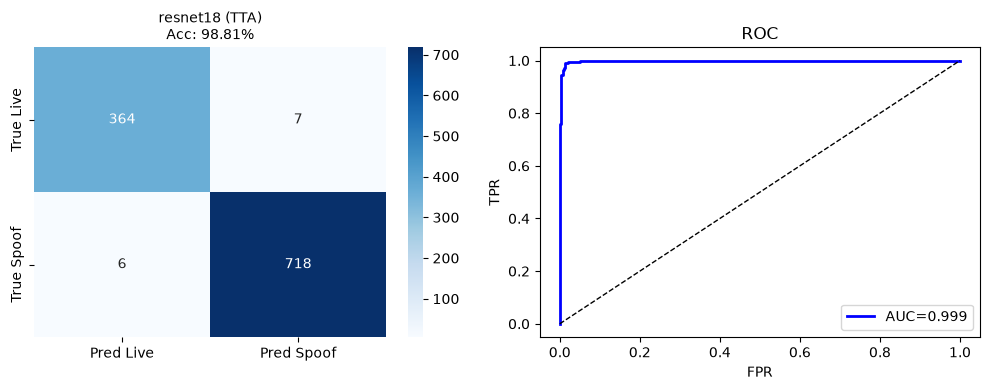

2026-06-30 12:00:57,963 | resnet18 -> ACC:98.81% ACER:1.36% AUC:0.9986
2026-06-30 12:00:57,970 | === Starting: densenet121 ===


resnet18 complete (TTA-evaluated). ACC=98.81% ACER=1.36% AUC=0.9986

############################################################
#  BACKBONE: densenet121
############################################################
  Ep    TrLoss    TrAcc    VaLoss    VaAcc   Loss mode
----------------------------------------------------------
   1    0.7860   75.14%    0.6353   84.47% <- best  weighted+LS
   2    0.5812   86.68%    0.5491   88.49% <- best  weighted+LS
   3    0.4757   91.33%    0.4988   91.69% <- best  weighted+LS
   4    0.4335   92.77%    0.4866   89.41%  weighted+LS
   5    0.3932   94.22%    0.4249   92.24% <- best  weighted+LS
   6    0.3631   95.08%    0.4158   92.42% <- best  weighted+LS
   7    0.3524   95.36%    0.3869   94.43% <- best  weighted+LS
   8    0.3292   96.32%    0.3750   95.07% <- best  weighted+LS
   9    0.3094   96.87%    0.3716   94.52%  weighted+LS
  10    0.3002   97.22%    0.3680   94.70%  weighted+LS
  11    0.2888   97.64%    0.3561   95.53% <- best  we

2026-06-30 14:12:53,228 | densenet121: switched to focal loss at epoch 20


  -> plateau detected at epoch 20, switching to focal loss (gamma=2.0)
  20    0.2758   98.18%    0.3673   94.70%  weighted+LS
  21    0.0474   98.43%    0.1147   95.16%       focal
  22    0.0521   98.07%    0.1184   95.16%       focal
  23    0.0503   98.29%    0.1187   94.98%       focal
  24    0.0498   98.11%    0.1158   95.34%       focal
  25    0.0551   97.87%    0.1249   94.70%       focal
  26    0.0506   98.24%    0.1195   95.07%       focal
  27    0.0431   98.54%    0.1139   95.34%       focal
  28    0.0496   98.13%    0.1177   94.89%       focal
  29    0.0455   98.48%    0.1170   95.07%       focal
  30    0.0512   98.09%    0.1153   95.53%       focal
Early stop at epoch 30


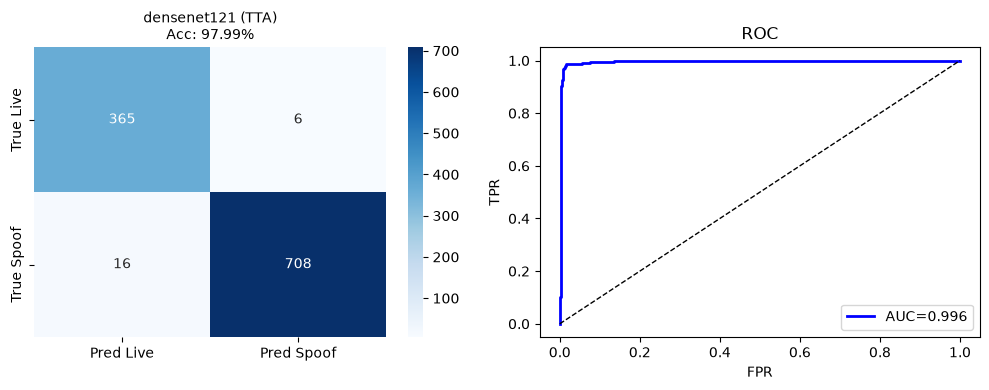

2026-06-30 15:33:06,681 | densenet121 -> ACC:97.99% ACER:1.91% AUC:0.9955
2026-06-30 15:33:06,714 | === Starting: vgg16 ===


densenet121 complete (TTA-evaluated). ACC=97.99% ACER=1.91% AUC=0.9955

############################################################
#  BACKBONE: vgg16
############################################################
  Ep    TrLoss    TrAcc    VaLoss    VaAcc   Loss mode
----------------------------------------------------------
   1    0.9000   67.69%    0.8145   74.52% <- best  weighted+LS
   2    0.8066   76.20%    0.7666   79.36% <- best  weighted+LS
   3    0.7551   79.81%    0.7337   81.00% <- best  weighted+LS
   4    0.7184   82.47%    0.7174   82.10% <- best  weighted+LS
   5    0.6880   84.43%    0.6827   84.02% <- best  weighted+LS
   6    0.6570   86.27%    0.6694   85.75% <- best  weighted+LS
   7    0.6481   86.44%    0.6311   88.04% <- best  weighted+LS
   8    0.6269   87.76%    0.6349   86.85%  weighted+LS
   9    0.5975   89.92%    0.6154   88.22% <- best  weighted+LS
  10    0.5859   90.61%    0.6078   89.04% <- best  weighted+LS
  11    0.5844   90.69%    0.6071   89.22

2026-06-30 18:31:12,884 | vgg16: switched to focal loss at epoch 21


  -> plateau detected at epoch 21, switching to focal loss (gamma=2.0)
  21    0.5664   92.00%    0.5936   90.14%  weighted+LS
  22    0.2849   91.91%    0.2951   90.23%       focal
  23    0.2839   92.03%    0.2938   90.23%       focal
  24    0.2815   92.43%    0.2929   90.32% <- best       focal
  25    0.2831   92.08%    0.2928   90.23%       focal
  26    0.2826   92.20%    0.2927   90.23%       focal
  27    0.2839   91.73%    0.2926   90.23%       focal
  28    0.2804   91.91%    0.2926   90.23%       focal
  29    0.2815   91.86%    0.2925   90.23%       focal
  30    0.2846   91.73%    0.2924   90.23%       focal
  31    0.2804   92.20%    0.2924   90.23%       focal
  32    0.2824   91.97%    0.2923   90.23%       focal
  33    0.2813   91.60%    0.2923   90.23%       focal
  34    0.2786   92.10%    0.2923   90.23%       focal
Early stop at epoch 34


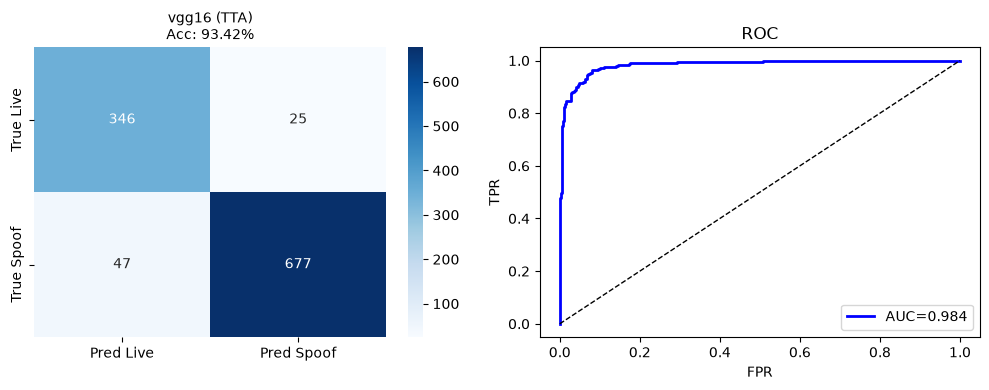

2026-06-30 20:00:45,352 | vgg16 -> ACC:93.42% ACER:6.62% AUC:0.9840
2026-06-30 20:00:45,371 | === Starting: mobilenetv2 ===


vgg16 complete (TTA-evaluated). ACC=93.42% ACER=6.62% AUC=0.9840

############################################################
#  BACKBONE: mobilenetv2
############################################################
  Ep    TrLoss    TrAcc    VaLoss    VaAcc   Loss mode
----------------------------------------------------------
   1    0.8366   71.69%    0.7760   78.90% <- best  weighted+LS
   2    0.7404   80.28%    0.7450   79.09% <- best  weighted+LS
   3    0.7006   82.36%    0.7431   78.72%  weighted+LS
   4    0.6750   84.35%    0.6822   82.19% <- best  weighted+LS
   5    0.6418   86.36%    0.6940   81.64%  weighted+LS
   6    0.6341   86.54%    0.6742   83.38% <- best  weighted+LS
   7    0.6134   87.29%    0.6260   86.30% <- best  weighted+LS
   8    0.5938   88.89%    0.6134   88.13% <- best  weighted+LS
   9    0.5697   90.09%    0.5997   87.85%  weighted+LS
  10    0.5730   89.99%    0.6031   88.49% <- best  weighted+LS
  11    0.5718   89.89%    0.6133   87.21%  weighted+LS
 

2026-06-30 21:44:21,388 | mobilenetv2: switched to focal loss at epoch 24


  -> plateau detected at epoch 24, switching to focal loss (gamma=2.0)
  24    0.5551   91.01%    0.5980   88.86%  weighted+LS
  25    0.2806   90.86%    0.3134   87.58%       focal
  26    0.2720   90.84%    0.3063   88.31%       focal
  27    0.2746   91.20%    0.3066   87.76%       focal
  28    0.2741   91.35%    0.3061   87.95%       focal
  29    0.2782   90.81%    0.3069   87.95%       focal
  30    0.2736   90.96%    0.3081   87.95%       focal
  31    0.2708   90.98%    0.2964   88.86%       focal
  32    0.2761   90.76%    0.3099   87.85%       focal
  33    0.2724   90.93%    0.3037   88.49%       focal
  34    0.2806   91.14%    0.3054   87.76%       focal
Early stop at epoch 34


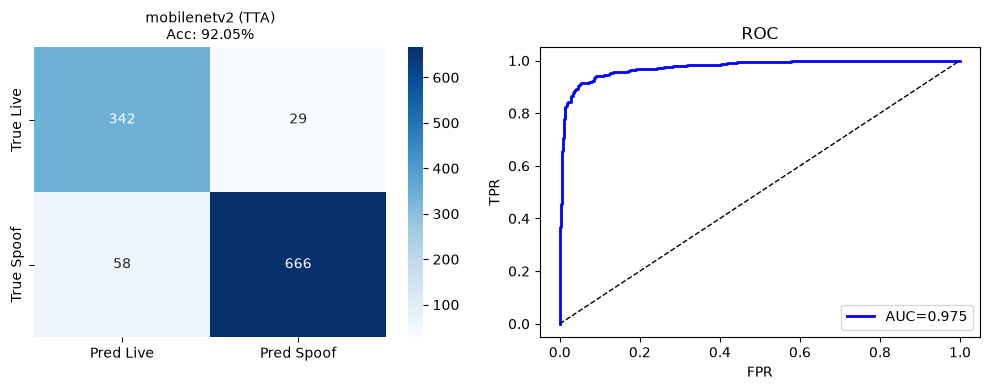

2026-06-30 22:24:05,754 | mobilenetv2 -> ACC:92.05% ACER:7.91% AUC:0.9751
2026-06-30 22:24:05,761 | === Starting: apbs_densenet121 ===


mobilenetv2 complete (TTA-evaluated). ACC=92.05% ACER=7.91% AUC=0.9751

############################################################
#  BACKBONE: apbs_densenet121
############################################################
  Ep    TrLoss    TrAcc    VaLoss    VaAcc   Loss mode
----------------------------------------------------------
   1    0.7871   74.72%    0.7536   77.72% <- best  weighted+LS
   2    0.5849   87.83%    0.5621   87.40% <- best  weighted+LS
   3    0.4764   91.26%    0.5189   88.49% <- best  weighted+LS
   4    0.4250   93.09%    0.4640   91.32% <- best  weighted+LS
   5    0.3921   93.91%    0.4340   92.69% <- best  weighted+LS
   6    0.3623   95.43%    0.4266   94.25% <- best  weighted+LS
   7    0.3326   96.20%    0.4068   93.97%  weighted+LS
   8    0.3268   96.47%    0.3896   94.06%  weighted+LS
   9    0.3130   96.53%    0.3751   94.98% <- best  weighted+LS
  10    0.2907   97.69%    0.3734   95.07% <- best  weighted+LS
  11    0.2838   97.67%    0.3702   95

2026-07-01 00:28:52,418 | apbs_densenet121: switched to focal loss at epoch 24


  -> plateau detected at epoch 24, switching to focal loss (gamma=2.0)
  24    0.2686   98.23%    0.3532   95.98%  weighted+LS
  25    0.0424   98.49%    0.1201   96.26%       focal
  26    0.0468   98.49%    0.1208   96.07%       focal
  27    0.0538   98.09%    0.1227   96.16%       focal
  28    0.0455   98.41%    0.1280   95.43%       focal
  29    0.0439   98.46%    0.1178   95.71%       focal
  30    0.0554   98.04%    0.1228   95.89%       focal
  31    0.0476   98.09%    0.1338   95.43%       focal
  32    0.0444   98.38%    0.1183   96.35%       focal
  33    0.0437   98.51%    0.1217   96.07%       focal
  34    0.0493   98.18%    0.1319   95.34%       focal
Early stop at epoch 34


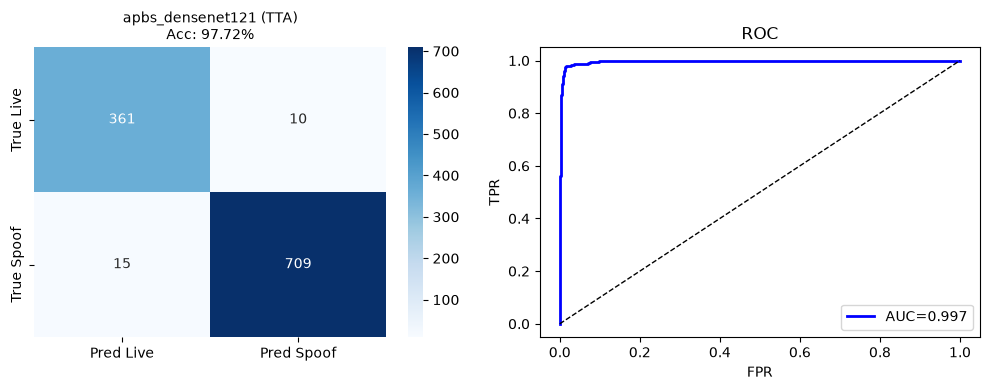

2026-07-01 01:23:43,430 | apbs_densenet121 -> ACC:97.72% ACER:2.38% AUC:0.9966


apbs_densenet121 complete (TTA-evaluated). ACC=97.72% ACER=2.38% AUC=0.9966


All 5 backbones complete.


In [9]:
# ---------------------------------------------------------------------------
# Sequential loop over all 5 backbones - 5 full trainings total.
# ---------------------------------------------------------------------------
all_results = []
for backbone_name in BACKBONE_NAMES:
    result = train_one_backbone(backbone_name, CONFIG)
    all_results.append(result)

print(f'\n\nAll {len(all_results)} backbones complete.')


## 10. Master Comparison Table + Headline Chart


  NDCLD15 MULTI-BACKBONE PBS BASELINE (TTA-EVALUATED) -- ALL 5 BACKBONES
        Backbone  Used focal fallback  Accuracy  APCER  BPCER  ACER    AUC
        resnet18                 True     98.81   0.83   1.89  1.36 0.9986
     densenet121                 True     97.99   2.21   1.62  1.91 0.9955
           vgg16                 True     93.42   6.49   6.74  6.62 0.9840
     mobilenetv2                 True     92.05   8.01   7.82  7.91 0.9751
apbs_densenet121                 True     97.72   2.07   2.70  2.38 0.9966


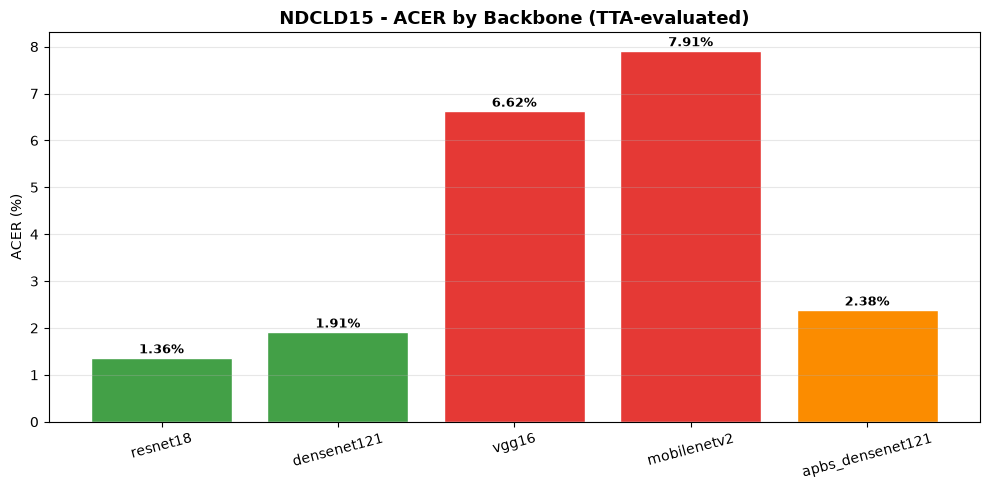

Saved → backbone_comparison_acer.png

Best backbone: resnet18 (ACER=1.36%, AUC=0.9986)


In [10]:
# ---------------------------------------------------------------------------
# Save the full comparison table and a bar chart of ACER per backbone.
# ---------------------------------------------------------------------------
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(METRICS_DIR / 'all_backbones_summary.csv', index=False)

print('=' * 100)
print('  NDCLD15 MULTI-BACKBONE PBS BASELINE (TTA-EVALUATED) -- ALL 5 BACKBONES')
print('=' * 100)
print(summary_df[['Backbone','Used focal fallback','Accuracy','APCER','BPCER','ACER','AUC']].to_string(index=False))
print('=' * 100)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#43A047' if v < 2 else '#FB8C00' if v < 5 else '#E53935' for v in summary_df['ACER']]
bars = ax.bar(summary_df['Backbone'], summary_df['ACER'], color=colors, edgecolor='white')
for bar, v in zip(bars, summary_df['ACER']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('NDCLD15 - ACER by Backbone (TTA-evaluated)', fontsize=13, fontweight='bold')
ax.set_ylabel('ACER (%)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'backbone_comparison_acer.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved \u2192 backbone_comparison_acer.png')

best_row = summary_df.loc[summary_df['ACER'].idxmin()]
print(f"\nBest backbone: {best_row['Backbone']} (ACER={best_row['ACER']:.2f}%, AUC={best_row['AUC']:.4f})")


## 11. Done


In [11]:
# ---------------------------------------------------------------------------
# Final confirmation + pointer to Notebook B.
# ---------------------------------------------------------------------------
print('\n' + '=' * 60)
print('  NOTEBOOK A COMPLETE -- NDCLD15 MULTI-BACKBONE BASELINE')
print('=' * 60)
for _, row in summary_df.iterrows():
    focal_note = ' (focal fallback used)' if row['Used focal fallback'] else ''
    print(f"  {row['Backbone']:20s}: ACC={row['Accuracy']:6.2f}%  ACER={row['ACER']:6.2f}%  AUC={row['AUC']:.4f}{focal_note}")
print('=' * 60)
print(f'\n  All outputs -> {EXP_DIR}')
print('\n\u27a1\ufe0f  Next -> Notebook B: TDA feature extraction for NDCLD15')



  NOTEBOOK A COMPLETE -- NDCLD15 MULTI-BACKBONE BASELINE
  resnet18            : ACC= 98.81%  ACER=  1.36%  AUC=0.9986 (focal fallback used)
  densenet121         : ACC= 97.99%  ACER=  1.91%  AUC=0.9955 (focal fallback used)
  vgg16               : ACC= 93.42%  ACER=  6.62%  AUC=0.9840 (focal fallback used)
  mobilenetv2         : ACC= 92.05%  ACER=  7.91%  AUC=0.9751 (focal fallback used)
  apbs_densenet121    : ACC= 97.72%  ACER=  2.38%  AUC=0.9966 (focal fallback used)

  All outputs -> C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp6_NDCLD15_MultiBackbone

➡️  Next -> Notebook B: TDA feature extraction for NDCLD15
